In [1]:
# Add src to path to allow importing net_epistemology without installing the package
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))


# Basic Testing

In this notebook we test that the main files work well.

## Setup

In [2]:
from net_epistemology.utils.imports import *
from net_epistemology.core.agents import BetaAgent, BayesAgent
from net_epistemology.core.model import Model

In [3]:
# n_agents = 100
# my_network = nx.gnp_random_graph(n_agents, p=0.2, directed=True) #nx.complete_graph(n_agents, create_using=nx.DiGraph())

In [4]:
# Save and load pud_final as JSON
import json
from networkx.readwrite import json_graph
from pathlib import Path

JSON_PATH = Path("../data/empirical_networks/pud_final.json")

# Save to JSON
def save_network_json(G, path):
    data = json_graph.node_link_data(G)
    with open(path, "w") as f:
        json.dump(data, f)
    print(f"Saved network to {path}")

# Load from JSON
def load_network_json(path):
    with open(path, "r") as f:
        data = json.load(f)
    # Fix for networkx expecting 'edges' instead of 'links' or vice-versa
    if "links" in data and "edges" not in data:
        data["edges"] = data["links"]
    G = json_graph.node_link_graph(data)
    print(f"Loaded network from {path}")
    return G

# Example usage:
# save_network_json(pud_final, JSON_PATH)
my_network = load_network_json(JSON_PATH)

Loaded network from ../data/empirical_networks/pud_final.json


/Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/.venv/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


## Try with Bayes Agent

In [5]:
seed=420
my_model = Model(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='bayes')
my_model.run_simulation(number_of_steps=10000,show_bar=True) #number_of_steps is a max amount\n",
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)
print('conclusion core', my_model.conclusion_core)
# df = pd.DataFrame(my_model.agent_histories)
# df.head(3)

100%|██████████| 10000/10000 [01:30<00:00, 110.71it/s]


steps:  10000
conclusion:  0.14743589743589744
conclusion core 0.2647058823529412


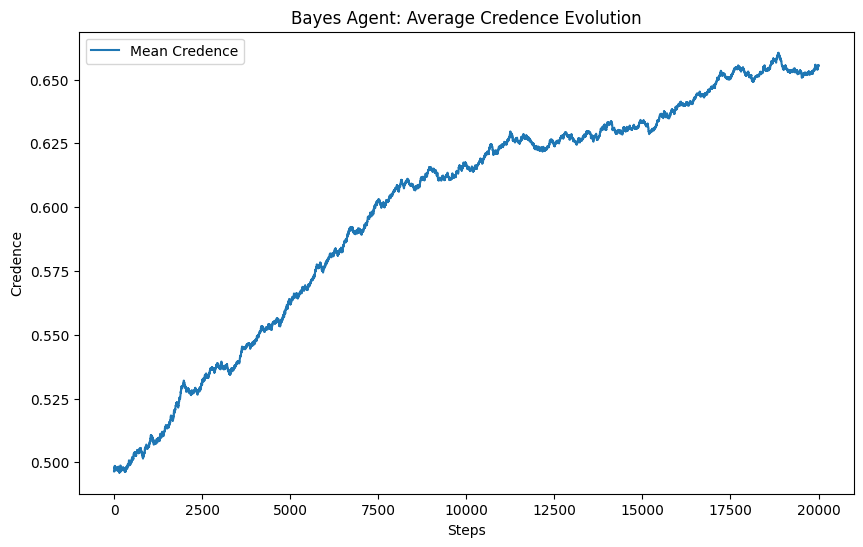

In [6]:
# Plot mean credence for Bayes
# Credences are 1D arrays (scalar per agent)
df_bayes = pd.DataFrame(my_model.agent_histories).T
df_bayes.head(3)
mean_credence = df_bayes.mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(mean_credence, label='Mean Credence')
plt.title('Bayes Agent: Average Credence Evolution')
plt.xlabel('Steps')
plt.ylabel('Credence')
plt.legend()
plt.show()

## Try with Beta Agent

In [7]:
seed=420
my_model = Model(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='beta')

my_model.run_simulation(number_of_steps=10000,show_bar=True) #number_of_steps is a max amount\n",
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)
df = pd.DataFrame(my_model.agent_histories)
df.head(3)

100%|██████████| 10000/10000 [22:10<00:00,  7.51it/s] 


steps:  10000
conclusion:  0.6602564102564102


,0,1,2,3,4,5,6,7,8,9,...,19991,19992,19993,19994,19995,19996,19997,19998,19999,20000
0,"[0.847057660934455, 0.7312622348344643]","[0.6664496918566056, 0.7312622348344643]","[0.6664496918566056, 0.10407034114573703]","[0.6613838573324127, 0.10407034114573703]","[0.6613838573324127, 0.8011600423836563]","[0.47758117947434175, 0.8011600423836563]","[0.47758117947434175, 0.40479347083489714]","[0.4491155959575251, 0.40479347083489714]","[0.4491155959575251, 0.24732145649261622]","[0.5608543266568825, 0.24732145649261622]",...,"[0.5011811527570134, 0.49979760971740705]","[0.5011811527570134, 0.4953288286703929]","[0.5045808319245696, 0.4953288286703929]","[0.5045808319245696, 0.497425876070481]","[0.4995489307521196, 0.497425876070481]","[0.4995489307521196, 0.5041248672607771]","[0.5022273163639048, 0.5041248672607771]","[0.5022273163639048, 0.5001306534050208]","[0.49935415155685264, 0.5001306534050208]","[0.49935415155685264, 0.5048566630565675]"
1,"[0.13161756720478318, 0.8543089037736713]","[0.0023403881337952515, 0.8543089037736713]","[0.0023403881337952515, 0.49680801632352817]","[0.04752219986459212, 0.49680801632352817]","[0.04752219986459212, 0.40678627636685144]","[0.4309231401347111, 0.40678627636685144]","[0.4309231401347111, 0.5090193483085689]","[0.33934062233740003, 0.5090193483085689]","[0.33934062233740003, 0.4705694737933726]","[0.4408957877429156, 0.4705694737933726]",...,"[0.4996644457269979, 0.5019033173595765]","[0.4996644457269979, 0.5014642450266554]","[0.5011732313886674, 0.5014642450266554]","[0.5011732313886674, 0.5045905100111248]","[0.5003846408603468, 0.5045905100111248]","[0.5003846408603468, 0.5035465566788542]","[0.49964724461504834, 0.5035465566788542]","[0.49964724461504834, 0.5021406979196736]","[0.5002378040410674, 0.5021406979196736]","[0.5002378040410674, 0.50323087178208]"
2,"[0.9983633760156501, 0.995187816332256]","[0.6493791833165802, 0.995187816332256]","[0.6493791833165802, 0.6442331214236183]","[0.7000741341408568, 0.6442331214236183]","[0.7000741341408568, 0.7334253219037074]","[0.6346358356305948, 0.7334253219037074]","[0.6346358356305948, 0.3673627543970746]","[0.4922174511802334, 0.3673627543970746]","[0.4922174511802334, 0.47864237894109496]","[0.42742605858978583, 0.47864237894109496]",...,"[0.500805061158189, 0.5007320796977909]","[0.500805061158189, 0.4987874732830787]","[0.5035610469481541, 0.4987874732830787]","[0.5035610469481541, 0.5035314717670659]","[0.5023773355643643, 0.5035314717670659]","[0.5023773355643643, 0.5031143828295281]","[0.5029901483484776, 0.5031143828295281]","[0.5029901483484776, 0.5043570030013269]","[0.5024125314619405, 0.5043570030013269]","[0.5024125314619405, 0.5050838796092958]"


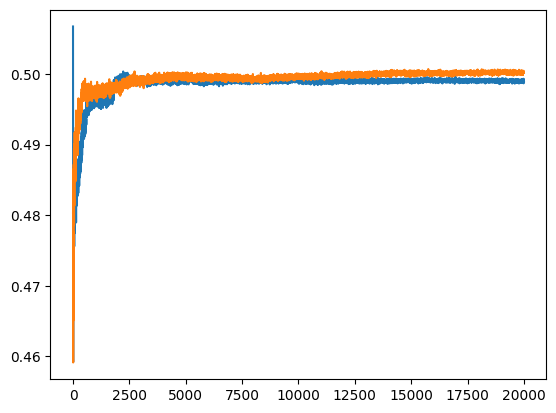

In [8]:
#Extract the first coordinate (x) for each pair and calculate column-wise mean
x_means = df.map(lambda pair: pair[0]).mean()
y_means = df.map(lambda pair: pair[1]).mean()
plt.plot(x_means)
plt.plot(y_means)

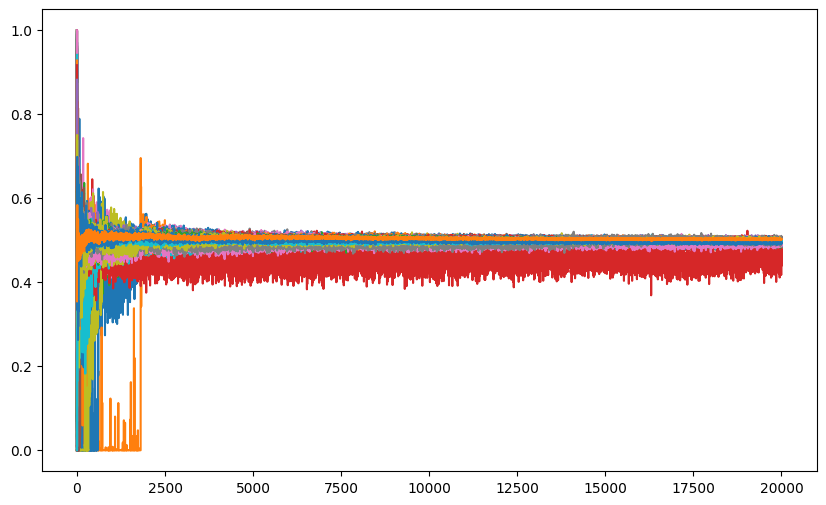

In [9]:
# Extract the first coordinate (x) for each pair
x_values = df.map(lambda pair: pair[0])

# Plot the first coordinate for each row
plt.figure(figsize=(10, 6))
for row_idx in range(x_values.shape[0]):
    plt.plot(x_values.columns, x_values.iloc[row_idx, :], label=f'Row {row_idx+1}' if row_idx < 5 else None)